## **Carga, limpieza y visualizacion del dataset**

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("librerías importadas correctamente")

librerías importadas correctamente


In [16]:
df = pd.read_csv('Sample-Superstore.csv', encoding='latin-1')
print(f"filas: {df.shape[0]}")
print(f"columnas: {df.shape[1]}")
df.head()

filas: 9994
columnas: 21


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


**revision inicial**

In [17]:
print("=== TIPOS DE DATOS ===")
print(df.dtypes)
print("\n=== VALORES NULOS ===")
print(df.isnull().sum())
print("\n=== DUPLICADOS ===")
print(f"Filas duplicadas: {df.duplicated().sum()}")

=== TIPOS DE DATOS ===
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

=== VALORES NULOS ===
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

==

**Limpieza**

In [ ]:
# Corregir fechas
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

# # Eliminar duplicados si los hay
# df = df.drop_duplicates()

# Columnas derivadas
df['Year']          = df['Order Date'].dt.year
df['Month']         = df['Order Date'].dt.month
df['Month Name']    = df['Order Date'].dt.strftime('%b')
df['Profit Margin'] = (df['Profit'] / df['Sales']).round(4)

print("Limpieza completada")
print(f"Shape final: {df.shape}")
df[['Order Date', 'Ship Date', 'Year', 'Month', 'Profit Margin']].head()

Limpieza completada
Shape final: (9994, 25)


,Order Date,Ship Date,Year,Month,Profit Margin
0,2016-11-08,2016-11-11,2016,11,0.1600
1,2016-11-08,2016-11-11,2016,11,0.3000
2,2016-06-12,2016-06-16,2016,6,0.4700
3,2015-10-11,2015-10-18,2015,10,-0.4000
4,2015-10-11,2015-10-18,2015,10,0.1125


In [19]:
print("=== RESUMEN GENERAL ===")
print(f"Período: {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")
print(f"Regiones: {df['Region'].unique()}")
print(f"Categorías: {df['Category'].unique()}")
print(f"Sub-categorías: {df['Sub-Category'].nunique()}")
print(f"Clientes únicos: {df['Customer Name'].nunique()}")
print(f"Productos únicos: {df['Product Name'].nunique()}")

=== RESUMEN GENERAL ===
Período: 2014-01-03 → 2017-12-30
Regiones: ['South' 'West' 'Central' 'East']
Categorías: ['Furniture' 'Office Supplies' 'Technology']
Sub-categorías: 17
Clientes únicos: 793
Productos únicos: 1850


## **EDA**

In [20]:
region = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
print(region.round(2))

             Sales     Profit
Region                       
West     725457.82  108418.45
East     678781.24   91522.78
Central  501239.89   39706.36
South    391721.90   46749.43


In [21]:
cat = df.groupby('Category')[['Sales', 'Profit', 'Profit Margin']].agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Profit Margin': 'mean'
}).round(2)
print(cat.sort_values('Profit', ascending=False))

                     Sales     Profit  Profit Margin
Category                                            
Technology       836154.03  145454.95           0.16
Office Supplies  719047.03  122490.80           0.14
Furniture        741999.80   18451.27           0.04


In [22]:
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
print("=== TODAS LAS SUB-CATEGORÍAS (de peor a mejor) ===")
print(subcat_profit.round(2))
print("\n=== SUB-CATEGORÍAS CON PÉRDIDAS ===")
print(subcat_profit[subcat_profit < 0].round(2))

=== TODAS LAS SUB-CATEGORÍAS (de peor a mejor) ===
Sub-Category
Tables        -17725.48
Bookcases      -3472.56
Supplies       -1189.10
Fasteners        949.52
Machines        3384.76
Labels          5546.25
Art             6527.79
Envelopes       6964.18
Furnishings    13059.14
Appliances     18138.01
Storage        21278.83
Chairs         26590.17
Binders        30221.76
Paper          34053.57
Accessories    41936.64
Phones         44515.73
Copiers        55617.82
Name: Profit, dtype: float64

=== SUB-CATEGORÍAS CON PÉRDIDAS ===
Sub-Category
Tables      -17725.48
Bookcases    -3472.56
Supplies     -1189.10
Name: Profit, dtype: float64


**tendecia anual de ventas**

In [23]:
yearly = df.groupby('Year')['Sales'].sum()
yoy = yearly.pct_change().mul(100).round(2)

print("=== VENTAS POR AÑO ===")
print(yearly.round(2))
print("\n=== CRECIMIENTO AÑO A AÑO (%) ===")
print(yoy)

=== VENTAS POR AÑO ===
Year
2014    484247.50
2015    470532.51
2016    609205.60
2017    733215.26
Name: Sales, dtype: float64

=== CRECIMIENTO AÑO A AÑO (%) ===
Year
2014      NaN
2015    -2.83
2016    29.47
2017    20.36
Name: Sales, dtype: float64


impacto del descuento en las ganancias

In [24]:
print("=== CORRELACIÓN DESCUENTO vs GANANCIA ===")
print(df[['Discount', 'Profit', 'Sales']].corr().round(3))

# Segmentado por nivel de descuento
df['Discount Band'] = pd.cut(df['Discount'],
    bins=[-0.01, 0, 0.2, 0.4, 1.0],
    labels=['Sin descuento', 'Bajo (0-20%)', 'Medio (20-40%)', 'Alto (>40%)'])

print("\n=== GANANCIA PROMEDIO POR NIVEL DE DESCUENTO ===")
print(df.groupby('Discount Band')['Profit'].mean().round(2))

=== CORRELACIÓN DESCUENTO vs GANANCIA ===
          Discount  Profit  Sales
Discount     1.000  -0.219 -0.028
Profit      -0.219   1.000  0.479
Sales       -0.028   0.479  1.000

=== GANANCIA PROMEDIO POR NIVEL DE DESCUENTO ===
Discount Band
Sin descuento      66.90
Bajo (0-20%)       26.50
Medio (20-40%)    -77.86
Alto (>40%)      -106.71
Name: Profit, dtype: float64


## **KPIs globales**

In [25]:
total_sales    = df['Sales'].sum()
total_profit   = df['Profit'].sum()
total_orders   = df['Order ID'].nunique()
overall_margin = (total_profit / total_sales * 100)

print("=" * 40)
print("        KPIs GENERALES DEL NEGOCIO")
print("=" * 40)
print(f"Ventas totales:      ${total_sales:>12,.2f}")
print(f"Ganancia total:      ${total_profit:>12,.2f}")
print(f"Margen general:      {overall_margin:>11.2f}%")
print(f"Órdenes totales:     {total_orders:>12,}")
print(f"Ticket promedio:     ${total_sales/total_orders:>12,.2f}")

        KPIs GENERALES DEL NEGOCIO
Ventas totales:      $2,297,200.86
Ganancia total:      $  286,397.02
Margen general:            12.47%
Órdenes totales:            5,009
Ticket promedio:     $      458.61


top 10 poductos más rentables

In [26]:
top_products = (df.groupby('Product Name')['Profit']
                  .sum()
                  .sort_values(ascending=False)
                  .head(10)
                  .reset_index())

top_products.columns = ['Product', 'Total Profit']
top_products['Total Profit'] = top_products['Total Profit'].round(2)
print(top_products.to_string(index=False))

                                                                    Product  Total Profit
                                      Canon imageCLASS 2200 Advanced Copier      25199.93
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind       7753.04
                                       Hewlett Packard LaserJet 3310 Copier       6983.88
                                         Canon PC1060 Personal Laser Copier       4570.93
                  HP Designjet T520 Inkjet Large Format Printer - 24" Color       4094.98
                                          Ativa V4110MDD Micro-Cut Shredder       3772.95
                           3D Systems Cube Printer, 2nd Generation, Magenta       3717.97
                 Plantronics Savi W720 Multi-Device Wireless Headset System       3696.28
                                       Ibico EPK-21 Electric Binding System       3345.28
                                          Zebra ZM400 Thermal Label Printer       3343.54


top 5 clientes más rentables

In [27]:
top_customers = (df.groupby('Customer Name')['Profit']
                   .sum()
                   .sort_values(ascending=False)
                   .head(5)
                   .reset_index())

top_customers.columns = ['Customer', 'Total Profit']
top_customers['Total Profit'] = top_customers['Total Profit'].round(2)
print(top_customers.to_string(index=False))

     Customer  Total Profit
 Tamara Chand       8981.32
 Raymond Buch       6976.10
 Sanjit Chand       5757.41
 Hunter Lopez       5622.43
Adrian Barton       5444.81


promedio de ventas mensuales

In [28]:
monthly_avg = (df.groupby(['Month', 'Month Name'])['Sales']
                 .sum()
                 .reset_index()
                 .sort_values('Month'))

print("=== VENTAS TOTALES POR MES (todos los años) ===")
print(monthly_avg[['Month Name', 'Sales']].to_string(index=False))

=== VENTAS TOTALES POR MES (todos los años) ===
Month Name       Sales
       Jan  94924.8356
       Feb  59751.2514
       Mar 205005.4888
       Apr 137762.1286
       May 155028.8117
       Jun 152718.6793
       Jul 147238.0970
       Aug 159044.0630
       Sep 307649.9457
       Oct 200322.9847
       Nov 352461.0710
       Dec 325293.5035


## **visualizaciones**

**Gráfica 1: Ventas y ganancia por región**

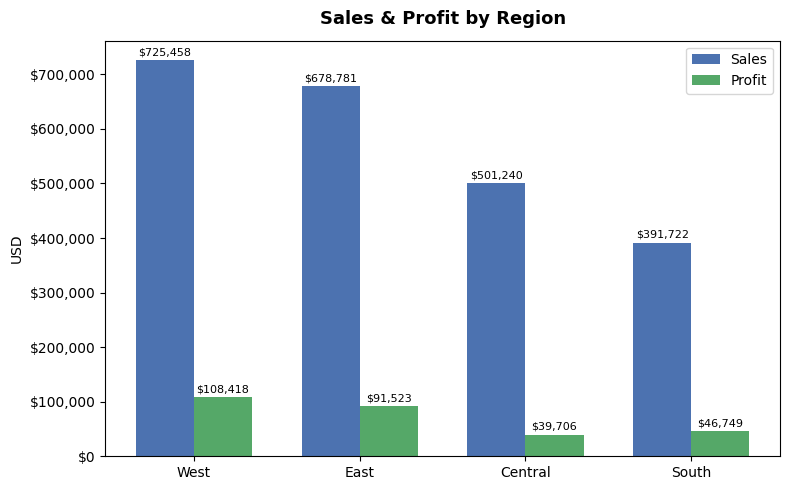

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))

region_data = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
x = range(len(region_data))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], region_data['Sales'],
               width=width, label='Sales', color='#4C72B0')
bars2 = ax.bar([i + width/2 for i in x], region_data['Profit'],
               width=width, label='Profit', color='#55A868')

ax.set_title('Sales & Profit by Region', fontsize=13, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(region_data.index)
ax.set_ylabel('USD')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('01_sales_profit_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

**Gráfica 2: Margen de ganancia por categoría**

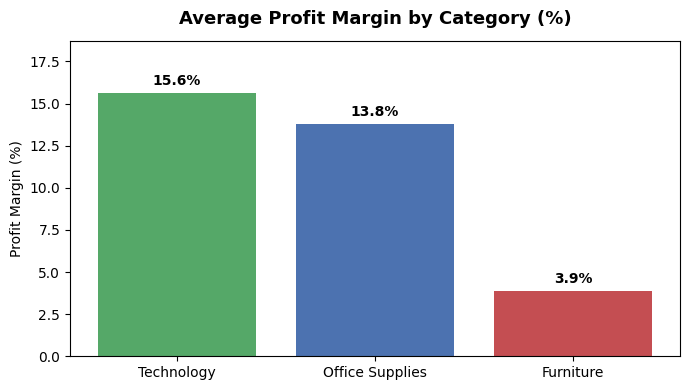

In [32]:
fig, ax = plt.subplots(figsize=(7, 4))

cat_margin = df.groupby('Category')['Profit Margin'].mean().sort_values(ascending=False)
colors = ['#55A868', '#4C72B0', '#C44E52']
bars = ax.bar(cat_margin.index, cat_margin.values * 100, color=colors)

ax.set_title('Average Profit Margin by Category (%)', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Profit Margin (%)')
ax.set_ylim(0, cat_margin.max() * 120)

for bar, val in zip(bars, cat_margin.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('02_profit_margin_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

**Gráfica 3: Tendencia de ventas por año**

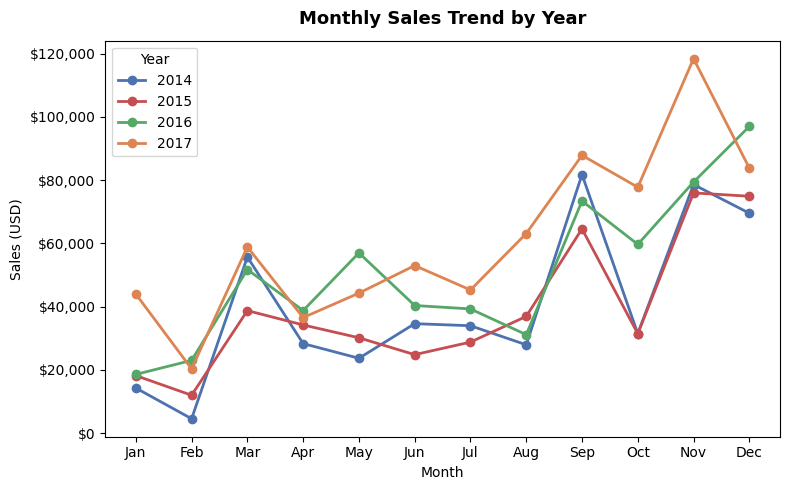

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))

monthly = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
colors_year = {2014: '#4C72B0', 2015: '#C44E52', 2016: '#55A868', 2017: '#DD8452'}

for year in sorted(monthly['Year'].unique()):
    subset = monthly[monthly['Year'] == year]
    ax.plot(subset['Month'], subset['Sales'],
            marker='o', linewidth=2, label=str(year),
            color=colors_year[year])

ax.set_title('Monthly Sales Trend by Year', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Sales (USD)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend(title='Year')

plt.tight_layout()
plt.savefig('03_monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

**Gráfica 4: Ganancia por sub-categoría**

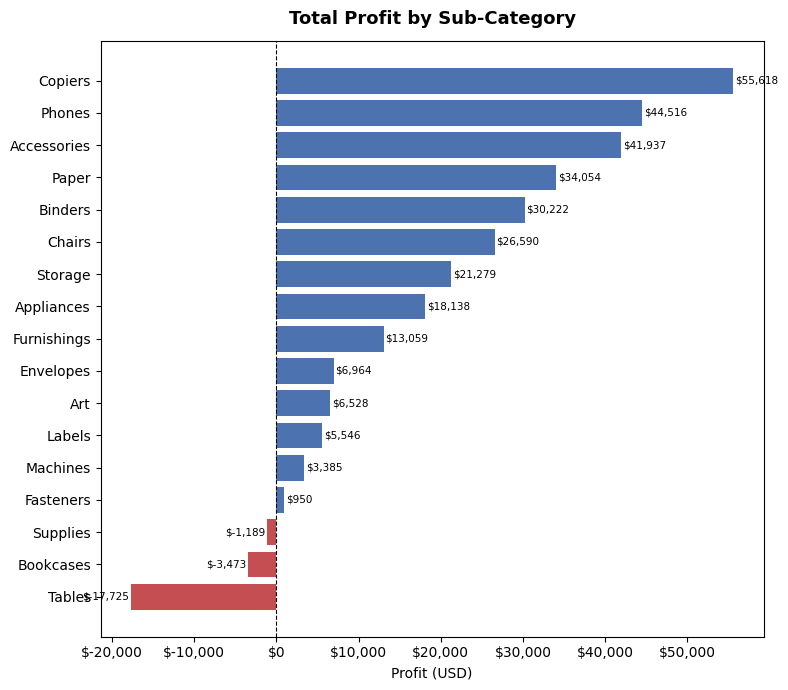

In [34]:
fig, ax = plt.subplots(figsize=(8, 7))

subcat = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['#C44E52' if v < 0 else '#4C72B0' for v in subcat.values]

bars = ax.barh(subcat.index, subcat.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Total Profit by Sub-Category', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Profit (USD)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))

for bar, val in zip(bars, subcat.values):
    offset = 200 if val >= 0 else -200
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', ha=ha, fontsize=7.5)

plt.tight_layout()
plt.savefig('04_profit_by_subcategory.png', dpi=150, bbox_inches='tight')
plt.show()

**Gráfica 5: Descuento vs Ganancia**

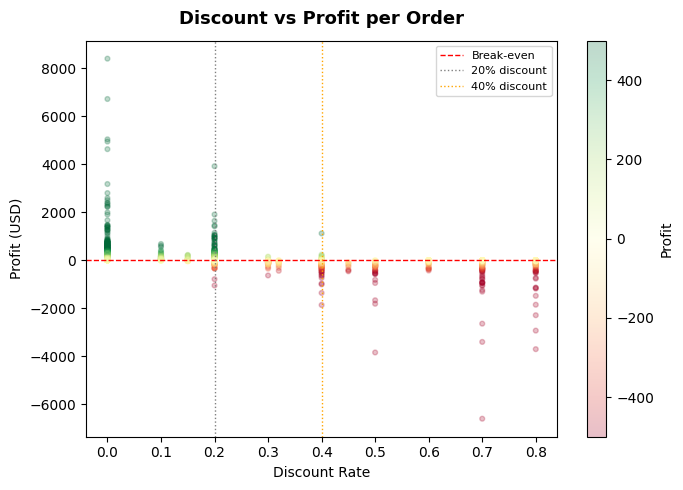

In [35]:
fig, ax = plt.subplots(figsize=(7, 5))

scatter = ax.scatter(df['Discount'], df['Profit'],
                     alpha=0.25, s=12,
                     c=df['Profit'], cmap='RdYlGn',
                     vmin=-500, vmax=500)

ax.axhline(0, color='red', linestyle='--', linewidth=1, label='Break-even')
ax.axvline(0.2, color='gray', linestyle=':', linewidth=1, label='20% discount')
ax.axvline(0.4, color='orange', linestyle=':', linewidth=1, label='40% discount')

ax.set_title('Discount vs Profit per Order', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Discount Rate')
ax.set_ylabel('Profit (USD)')
ax.legend(fontsize=8)
plt.colorbar(scatter, ax=ax, label='Profit')

plt.tight_layout()
plt.savefig('05_discount_vs_profit.png', dpi=150, bbox_inches='tight')
plt.show()

**Gráfica 6: Estacionalidad mensual**

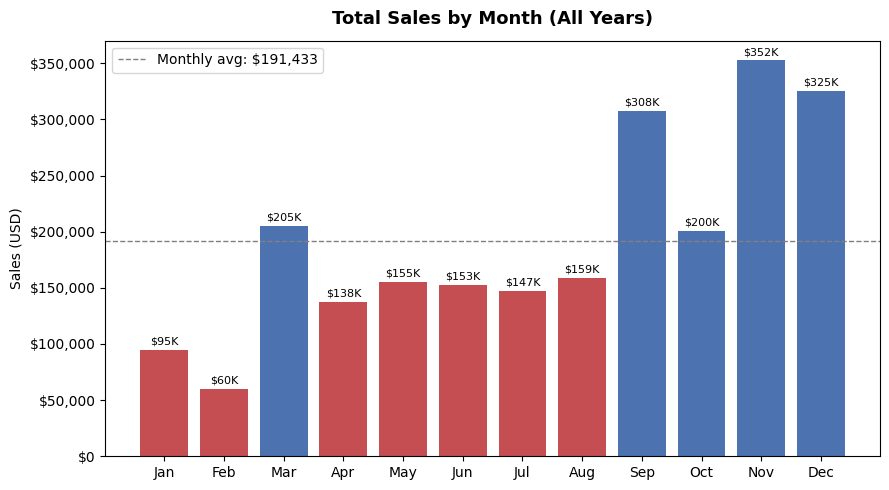

In [36]:
fig, ax = plt.subplots(figsize=(9, 5))

month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_total = (df.groupby('Month Name')['Sales']
                   .sum()
                   .reindex(month_order))

bar_colors = ['#C44E52' if v < monthly_total.mean() else '#4C72B0'
              for v in monthly_total.values]

bars = ax.bar(monthly_total.index, monthly_total.values, color=bar_colors)
ax.axhline(monthly_total.mean(), color='gray', linestyle='--',
           linewidth=1, label=f'Monthly avg: ${monthly_total.mean():,.0f}')

ax.set_title('Total Sales by Month (All Years)', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Sales (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend()

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
            f'${bar.get_height()/1000:.0f}K',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('06_monthly_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

## **Resumen ejecutivo**

In [37]:
print("""
╔══════════════════════════════════════════════════════════╗
║           SUPERSTORE SALES ANALYSIS — SUMMARY           ║
╚══════════════════════════════════════════════════════════╝

BUSINESS OVERVIEW
─────────────────
  Total Sales:        $2,297,200.86
  Total Profit:       $  286,397.02
  Overall Margin:           12.47%
  Total Orders:              5,009
  Average Order Value:     $458.61

KEY FINDINGS
────────────
  1. West leads in sales ($725K) but South shows stronger
     profit efficiency relative to its sales volume.

  2. Technology is the most profitable category (16% margin).
     Furniture generates $742K in sales but retains only 4
     cents per dollar — the lowest margin by far.

  3. Three sub-categories are losing money:
     · Tables:    -$17,725
     · Bookcases:  -$3,472
     · Supplies:   -$1,189

  4. Discounts above 20% consistently destroy profit.
     · No discount:    +$66.90 avg profit per order
     · High (>40%):   -$106.71 avg profit per order

  5. Sales peak in Sep, Nov, and Dec every year.
     November alone accounts for $352K across all years.

  6. Strong recovery after 2015 dip: +29.47% in 2016,
     +20.36% in 2017.

RECOMMENDATIONS
───────────────
  · Eliminate or reprice Tables and Bookcases immediately.
  · Cap discounts at 20% company-wide.
  · Expand Technology product lines — highest ROI.
  · Align inventory and marketing with Q4 seasonality.
""")


╔══════════════════════════════════════════════════════════╗
║           SUPERSTORE SALES ANALYSIS — SUMMARY           ║
╚══════════════════════════════════════════════════════════╝

BUSINESS OVERVIEW
─────────────────
  Total Sales:        $2,297,200.86
  Total Profit:       $  286,397.02
  Overall Margin:           12.47%
  Total Orders:              5,009
  Average Order Value:     $458.61

KEY FINDINGS
────────────
  1. West leads in sales ($725K) but South shows stronger
     profit efficiency relative to its sales volume.

  2. Technology is the most profitable category (16% margin).
     Furniture generates $742K in sales but retains only 4
     cents per dollar — the lowest margin by far.

  3. Three sub-categories are losing money:
     · Tables:    -$17,725
     · Bookcases:  -$3,472
     · Supplies:   -$1,189

  4. Discounts above 20% consistently destroy profit.
     · No discount:    +$66.90 avg profit per order
     · High (>40%):   -$106.71 avg profit per order

  5. Sa